[' happy']
Counter({' happy': 1})


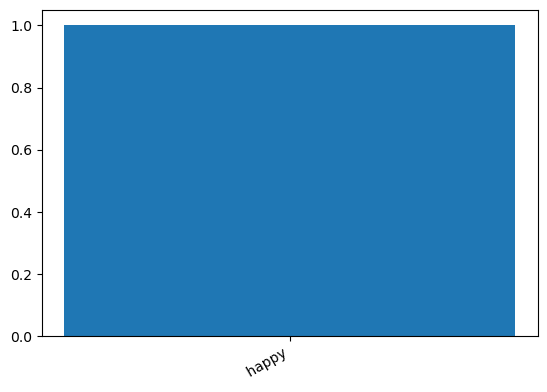

In [27]:
from googletrans import Translator
import string
from collections import Counter
import matplotlib.pyplot as plt

# Initialize the Translator
translator = Translator()

# Function to translate text to English
def translate_to_english(text):
    translated = translator.translate(text, src='auto', dest='en')
    return translated.text

# Reading text file
text = open("read.txt", encoding="utf-8").read()

# Translate text to English
translated_text = translate_to_english(text)

# Converting to lowercase
lower_case = translated_text.lower()

# Removing punctuations
cleaned_text = lower_case.translate(str.maketrans('', '', string.punctuation))

# Splitting text into words
tokenized_words = cleaned_text.split()

# Stop words list
stop_words = ["i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours", "yourself",
              "yourselves", "he", "him", "his", "himself", "she", "her", "hers", "herself", "it", "its", "itself",
              "they", "them", "their", "theirs", "themselves", "what", "which", "who", "whom", "this", "that", "these",
              "those", "am", "is", "are", "was", "were", "be", "been", "being", "have", "has", "had", "having", "do",
              "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or", "because", "as", "until", "while",
              "of", "at", "by", "for", "with", "about", "against", "between", "into", "through", "during", "before",
              "after", "above", "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under", "again",
              "further", "then", "once", "here", "there", "when", "where", "why", "how", "all", "any", "both", "each",
              "few", "more", "most", "other", "some", "such", "no", "nor", "not", "only", "own", "same", "so", "than",
              "too", "very", "s", "t", "can", "will", "just", "don", "should", "now"]


# Removing stop words from the tokenized words list
final_words = [word for word in tokenized_words if word not in stop_words]


# NLP Emotion Algorithm
emotion_list = []
with open('emotions.txt', 'r') as file:
    for line in file:
        clear_line = line.replace("\n", '').replace(",", '').replace("'", '').strip()
        word, emotion = clear_line.split(':')

        if word in final_words:
            emotion_list.append(emotion)

print(emotion_list)
w = Counter(emotion_list)
print(w)

# Plotting the emotions on the graph
fig, ax1 = plt.subplots()
ax1.bar(w.keys(), w.values())
fig.autofmt_xdate()
plt.savefig('graph.png')
plt.show()


In [28]:
# Debugging translation
print("Original Text:", text)
print("Translated Text:", translated_text)

# Debugging tokenized words
print("Tokenized Words:", tokenized_words)

# Debugging final words after removing stop words
print("Final Words:", final_words)

# Debugging detected emotions
print("Detected Emotions:", emotion_list)

# Debugging word-emotion counter
print("Emotion Counter:", w)


Original Text: Regular exercise is one of the best things you can do for your body and mind. Whether you're taking a brisk walk, engaging in a workout at the gym, or practicing yoga, the benefits are undeniable.

First and foremost, exercise is key to maintaining a healthy body. It helps improve cardiovascular health by strengthening the heart, reducing the risk of diseases such as high blood pressure, heart disease, and stroke. It also helps to manage weight, as physical activity burns calories, boosts metabolism, and supports the body's ability to build and maintain muscle mass.

But the benefits of exercise go beyond physical health. Regular activity is known to reduce symptoms of anxiety, depression, and stress. It triggers the release of endorphins, often referred to as "feel-good" hormones, which improve mood and increase feelings of happiness. This makes exercise an effective tool in boosting mental well-being and promoting better sleep.

Exercise also enhances brain function. S

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/himanshujha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Transcription: aaj main bahut hi Achcha feel kar raha hun per main bahut ganda bhi feel kar raha hun aur main bahut confuse bhi feel kar raha hun aur main bahut
Text from file: Regular exercise is one of the best things you can do for your body and mind. Whether you're taking a brisk walk, engaging in a workout at the gym, or practicing yoga, the benefits are undeniable.

First and foremost, exercise is key to maintaining a healthy body. It helps improve cardiovascular health by strengthening the heart, reducing the risk of diseases such as high blood pressure, heart disease, and stroke. It also helps to manage weight, as physical activity burns calories, boosts metabolism, and supports the body's ability to build and maintain muscle mass.

But the benefits of exercise go beyond physical health. Regular activity is known to reduce symptoms of anxiety, depression, and stress. It triggers the release of endorphins, often referred to as "feel-good" hormones, which improve mood and increas

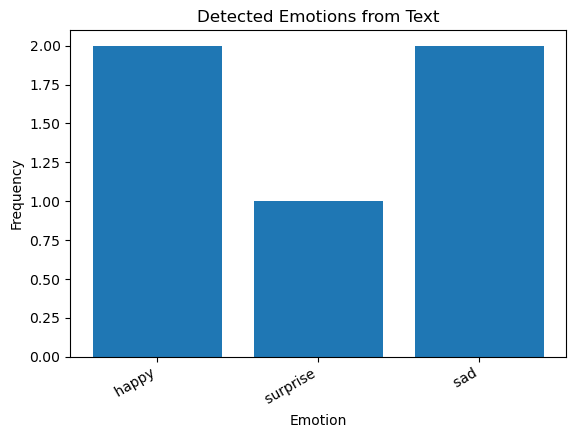

In [39]:
# Import necessary libraries
from googletrans import Translator  # For translating text to English
import speech_recognition as sr  # For transcribing audio to text
from transformers import pipeline  # For sentiment analysis using pre-trained models
import string  # For string manipulation
from collections import Counter  # For counting occurrences of emotions
import matplotlib.pyplot as plt  # For plotting graphs
import nltk  # For natural language processing tasks like sentence tokenization

# Ensure you have the Punkt tokenizer models for sentence splitting
nltk.download('punkt')

# Initialize the Translator object for translation
translator = Translator()

# Initialize the recognizer object for speech recognition
recognizer = sr.Recognizer()

# Reading the text file (text data) into a string variable
with open("read.txt", encoding="utf-8") as file:
    text = file.read()

# Specify the WAV file that will be transcribed into text
audio_file = "converted_audio.wav"

# Open and transcribe the audio file using the recognizer object
with sr.AudioFile(audio_file) as source:
    audio = recognizer.record(source)  # Record the audio file
    
    try:
        # Attempt to transcribe the audio using Google's Web Speech API
        text_1 = recognizer.recognize_google(audio)
        print("Transcription: " + text_1)  # Print the transcribed text
    except sr.UnknownValueError:
        # If speech recognition fails due to unclear speech, handle the error
        print("Google Speech Recognition could not understand the audio.")
        text_1 = ""  # Assign an empty string if no transcription is possible
    except sr.RequestError:
        # If there's an issue with the Google API request, handle the error
        print("Could not request results from Google Speech Recognition service.")
        text_1 = ""  # Assign an empty string in case of error

# Function to translate any text into English
def translate_to_english(text):
    # Use the Translator to translate text to English from any language (auto-detecting the language)
    translated = translator.translate(text, src='auto', dest='en')
    return translated.text  # Return the translated text

# Translate both the text from the file and the transcribed audio into English
translated_text = translate_to_english(text)
translated_text_1 = translate_to_english(text_1)

# Merge both the translated texts (from file and audio) into a single string for processing
final_text = translated_text + " " + translated_text_1

# Print both the translated texts for debugging purposes
print(f"Text from file: {translated_text}")
print(f"Transcribed text from audio: {translated_text_1}")

# Split the final combined text into individual sentences for sentiment analysis
sentences = nltk.sent_tokenize(final_text)

# Initialize the sentiment analysis pipeline using the distillBERT model
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0)

# List to hold sentiment results for each sentence
all_sentiments = []

# Iterate over each sentence and perform sentiment analysis
for sentence in sentences:
    sentiment_result = sentiment_pipeline(sentence)  # Get sentiment for each sentence
    all_sentiments.append((sentence, sentiment_result))  # Store the sentence and its sentiment result

# Print the sentiment analysis results for each sentence
print("Sentiments for each sentence:")
for sentence, sentiment in all_sentiments:
    print(f"Sentence: {sentence}")
    print(f"Sentiment: {sentiment}")

# Count the number of positive sentences by checking sentiment labels
positive_count = sum(1 for _, sentiment in all_sentiments if sentiment[0]['label'] == 'POSITIVE')
# Count the number of negative sentences (total sentences - positive sentences)
negative_count = len(all_sentiments) - positive_count

# Print the overall sentiment counts (positive and negative sentences)
print(f"Positive Sentences: {positive_count}")
print(f"Negative Sentences: {negative_count}")

# Emotion Lexicon Approach - Mapping words to emotions
emotion_list = []

# Open the 'emotions.txt' file that contains word-emotion mappings
with open('emotions.txt', 'r') as file:
    # Iterate over each line in the file
    for line in file:
        # Clean up the line by removing newline characters and commas, then splitting into word and emotion
        clear_line = line.replace("\n", '').replace(",", '').replace("'", '').strip()
        word, emotion = clear_line.split(':')

        # Check if the word is found in any of the sentences
        for sentence in sentences:
            # Perform a case-insensitive check for the presence of the word in the sentence
            if word in sentence.lower():
                # If the word is found, append the emotion to the emotion list
                emotion_list.append(emotion)

# Count the frequency of each detected emotion
emotion_counter = Counter(emotion_list)

# Print the detected emotions and their frequencies
print("Detected emotions:", emotion_counter)

# Plot the emotions as a bar chart
fig, ax = plt.subplots()
ax.bar(emotion_counter.keys(), emotion_counter.values())  # Create a bar plot
fig.autofmt_xdate()  # Automatically format x-axis labels for better readability
plt.title("Detected Emotions from Text")  # Set the title of the graph
plt.xlabel("Emotion")  # Label for the x-axis
plt.ylabel("Frequency")  # Label for the y-axis
plt.savefig('emotion_graph.png')  # Save the plot as a PNG file
plt.show()  # Display the plot



In [30]:
# Debugging translation
print("Original Text:", final_text)
print("Translated Text:", translated_text)
print("Translated Text:", translated_text_1)
# Debugging tokenized words
print("Tokenized Words:", tokenized_words)

# Debugging final words after removing stop words
print("Final Words:", final_words)

# Debugging detected emotions
print("Detected Emotions:", emotion_list)

# Debugging word-emotion counter
print("Emotion Counter:", w)

Original Text: Regular exercise is one of the best things you can do for your body and mind. Whether you're taking a brisk walk, engaging in a workout at the gym, or practicing yoga, the benefits are undeniable.

First and foremost, exercise is key to maintaining a healthy body. It helps improve cardiovascular health by strengthening the heart, reducing the risk of diseases such as high blood pressure, heart disease, and stroke. It also helps to manage weight, as physical activity burns calories, boosts metabolism, and supports the body's ability to build and maintain muscle mass.

But the benefits of exercise go beyond physical health. Regular activity is known to reduce symptoms of anxiety, depression, and stress. It triggers the release of endorphins, often referred to as "feel-good" hormones, which improve mood and increase feelings of happiness. This makes exercise an effective tool in boosting mental well-being and promoting better sleep.

Exercise also enhances brain function. S

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/himanshujha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Transcription: aaj main bahut hi Achcha feel kar raha hun per main bahut ganda bhi feel kar raha hun aur main bahut confuse bhi feel kar raha hun aur main bahut
Detected emotions from words: Counter({'neutral': 349, 'sadness': 17, 'disgust': 8, 'joy': 7, 'fear': 6, 'anger': 2})


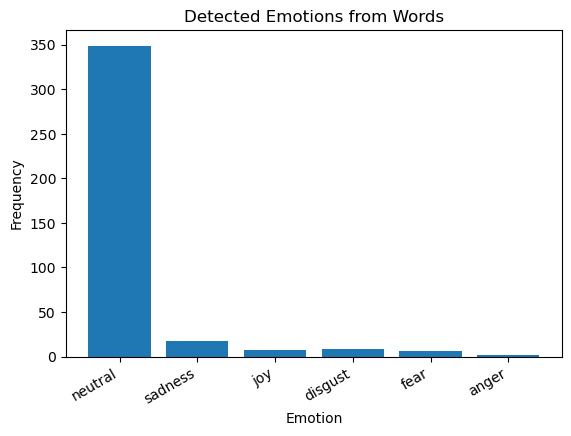

In [41]:
# Import necessary libraries
from transformers import pipeline  # For emotion detection using pre-trained models
import nltk  # For natural language processing tasks like word tokenization
from collections import Counter  # For counting occurrences of emotions
import matplotlib.pyplot as plt  # For plotting graphs

# Ensure you have the Punkt tokenizer models for tokenizing text into words
nltk.download('punkt')

# Initialize the emotion detection pipeline using a pre-trained model
# The model "j-hartmann/emotion-english-distilroberta-base" detects emotions from text
emotion_pipeline = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", 
                            tokenizer="j-hartmann/emotion-english-distilroberta-base", device=0)

# Reading the text file ('read.txt') containing textual feedback
with open("read.txt", encoding="utf-8") as file:
    text = file.read()  # Store the contents of the file in the 'text' variable

# Specify the audio file for transcription ('converted_audio.wav')
audio_file = "converted_audio.wav"

# Open and transcribe the audio file using the recognizer object
with sr.AudioFile(audio_file) as source:
    audio = recognizer.record(source)  # Record the audio data from the file
    
    try:
        # Use Google's Web Speech API to convert speech to text
        text_1 = recognizer.recognize_google(audio)
        print("Transcription: " + text_1)  # Print the transcribed text
    except sr.UnknownValueError:
        # Handle the case where speech recognition fails due to unclear speech
        print("Google Speech Recognition could not understand the audio.")
        text_1 = ""  # If there's no transcription, assign an empty string
    except sr.RequestError:
        # Handle errors related to requesting the results from Google's API
        print("Could not request results from Google Speech Recognition service.")
        text_1 = ""  # If there’s an API error, assign an empty string

# Merge the text from both the file and the transcribed audio into one string
final_text = text + " " + text_1

# Split the combined text into individual words using nltk's word tokenizer
words = nltk.word_tokenize(final_text)

# List to store the emotions detected at the word level
word_emotions = []

# Iterate over each word in the tokenized text
for word in words:
    # Get the emotion prediction for each word using the emotion detection pipeline
    result = emotion_pipeline(word)
    
    # Extract the predicted emotion label from the result
    emotion = result[0]['label']
    
    # Append the detected emotion to the word_emotions list
    word_emotions.append(emotion)

# Count the frequency of each emotion in the word_emotions list
emotion_counter = Counter(word_emotions)

# Print the detected emotions and their frequencies
print("Detected emotions from words:", emotion_counter)

# Plotting the emotions as a bar chart using matplotlib
fig, ax = plt.subplots()  # Create a new figure and axes for plotting
ax.bar(emotion_counter.keys(), emotion_counter.values())  # Plot the emotion frequencies as bars
fig.autofmt_xdate()  # Format x-axis labels to avoid overlap and make them readable

# Set the title and labels for the graph
plt.title("Detected Emotions from Words")
plt.xlabel("Emotion")  # Label for the x-axis
plt.ylabel("Frequency")  # Label for the y-axis

# Save the plot as a PNG image
plt.savefig('emotion_graph_word_level.png')

# Display the plot on the screen
plt.show()
